In [1]:
pip install lightgbm shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.4 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


IPL Live Win Predictor — LightGBM

Step 1 — Loading and splitting by match
Train: 860 matches → 15507 over-snapshots
Test : 216 matches → 3950 over-snapshots
Target balance (train): 0.418

Step 2 — Training LightGBM

CV Accuracy: 0.9676 ± 0.0040
CV per fold: [np.float64(0.9707), np.float64(0.9697), np.float64(0.9668), np.float64(0.9707), np.float64(0.96)]

Model trained — 500 trees

Step 3 — Evaluating

── Test Set Results ──
Accuracy : 0.7714
Log-Loss : 0.5321

Classification Report:
                   precision    recall  f1-score   support

Bowling team wins       0.80      0.80      0.80      2288
Batting team wins       0.73      0.73      0.73      1662

         accuracy                           0.77      3950
        macro avg       0.77      0.77      0.77      3950
     weighted avg       0.77      0.77      0.77      3950



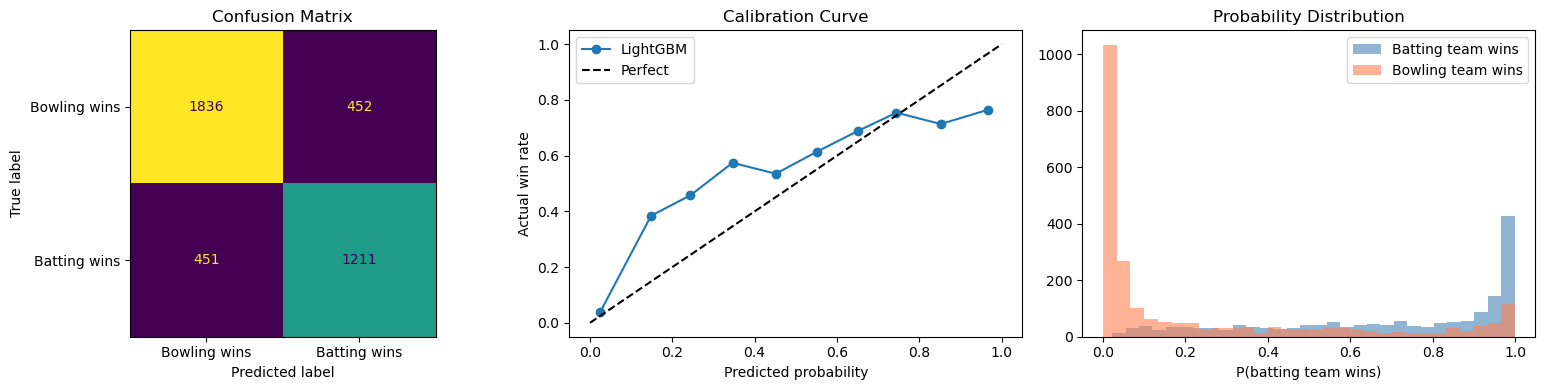

Saved → live_evaluation.png

Step 4 — Win probability curves


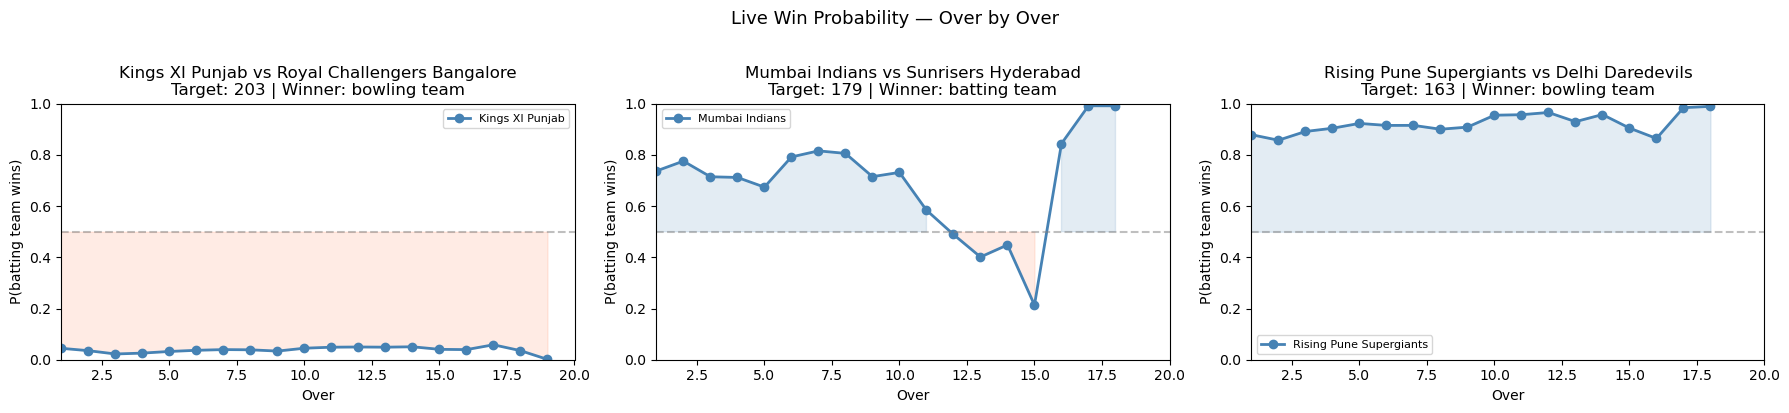

Saved → live_win_probability_curves.png

Step 5 — SHAP explainability


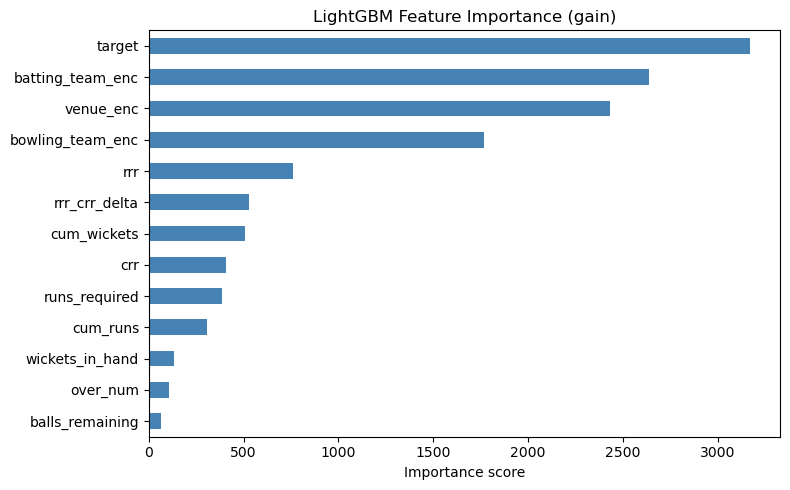

Saved → live_feature_importance.png


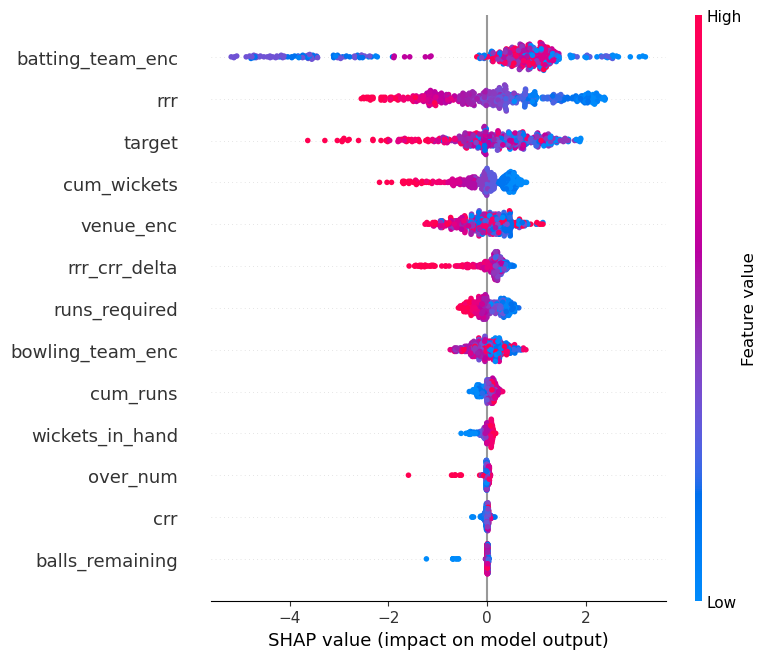

Saved → live_shap_summary.png


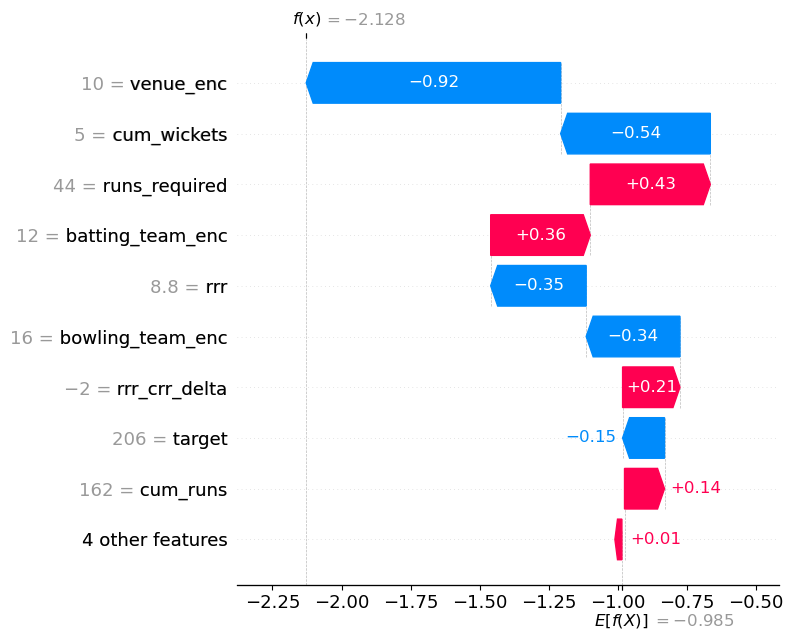

Saved → live_shap_waterfall.png

Step 6 — Saving model
Saved → live_model.pkl

✓ Done!
  Test accuracy : 0.7714
  Test log-loss : 0.5321
  Artifacts: live_model.pkl, live_evaluation.png,
             live_win_probability_curves.png, live_shap_summary.png


In [5]:
"""
IPL Win Predictor — Live (Mid-Match) LightGBM Model
=====================================================
Input:  live_features.csv  (output of ipl_feature_engineering.py)
Output: live_model.pkl     (trained LightGBM model + explainer)

Sections:
  1. Load & time-based split
  2. Train LightGBM
  3. Evaluate (accuracy, log-loss, calibration)
  4. Win probability curve (over-by-over)
  5. SHAP explainability
  6. Save model
  7. Predict function (used by Streamlit app)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, log_loss,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
import shap


# ─────────────────────────────────────────────
# 1. LOAD & TIME-BASED SPLIT
# ─────────────────────────────────────────────

FEATURES = [
    "batting_team_enc", "bowling_team_enc", "venue_enc",
    "over_num",
    "cum_runs", "cum_wickets",
    "target", "runs_required", "balls_remaining",
    "wickets_in_hand",
    "crr", "rrr", "rrr_crr_delta",
]
TARGET = "batting_team_won"

def load_and_split(path="live_features.csv", test_match_frac=0.2):
    """
    Split by match_id — all overs of a match stay together in
    either train or test. Never split mid-match.
    """
    df = pd.read_csv(path)

    # Shuffle match ids then split
    match_ids = df["match_id"].unique()
    np.random.seed(42)
    np.random.shuffle(match_ids)

    cutoff = int(len(match_ids) * (1 - test_match_frac))
    train_ids = set(match_ids[:cutoff])
    test_ids  = set(match_ids[cutoff:])

    train = df[df["match_id"].isin(train_ids)]
    test  = df[df["match_id"].isin(test_ids)]

    X_train = train[FEATURES]
    y_train = train[TARGET]
    X_test  = test[FEATURES]
    y_test  = test[TARGET]

    print(f"Train: {len(train_ids)} matches → {len(train)} over-snapshots")
    print(f"Test : {len(test_ids)} matches → {len(test)} over-snapshots")
    print(f"Target balance (train): {y_train.mean():.3f}")

    return X_train, y_train, X_test, y_test, train, test


# ─────────────────────────────────────────────
# 2. TRAIN LIGHTGBM
# ─────────────────────────────────────────────

def train_model(X_train, y_train):
    model = lgb.LGBMClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1,
    )

    # 5-fold stratified CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"\nCV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"CV per fold: {[round(s, 4) for s in cv_scores]}")

    model.fit(X_train, y_train)
    print(f"\nModel trained — {model.n_estimators} trees")
    return model


# ─────────────────────────────────────────────
# 3. EVALUATE
# ─────────────────────────────────────────────

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    ll  = log_loss(y_test, y_prob)

    print("\n── Test Set Results ──")
    print(f"Accuracy : {acc:.4f}")
    print(f"Log-Loss : {ll:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=["Bowling team wins", "Batting team wins"]))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Bowling wins", "Batting wins"],
        ax=axes[0], colorbar=False
    )
    axes[0].set_title("Confusion Matrix")

    # Calibration curve
    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    axes[1].plot(prob_pred, prob_true, marker="o", label="LightGBM")
    axes[1].plot([0, 1], [0, 1], "k--", label="Perfect")
    axes[1].set_xlabel("Predicted probability")
    axes[1].set_ylabel("Actual win rate")
    axes[1].set_title("Calibration Curve")
    axes[1].legend()

    # Probability distribution by over
    axes[2].hist(y_prob[y_test == 1], bins=30, alpha=0.6,
                 label="Batting team wins", color="steelblue")
    axes[2].hist(y_prob[y_test == 0], bins=30, alpha=0.6,
                 label="Bowling team wins", color="coral")
    axes[2].set_xlabel("P(batting team wins)")
    axes[2].set_title("Probability Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig("live_evaluation.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → live_evaluation.png")

    return acc, ll


# ─────────────────────────────────────────────
# 4. WIN PROBABILITY CURVE (over-by-over)
#    The most visually impressive output —
#    shows how win probability shifts each over
# ─────────────────────────────────────────────

def plot_win_probability_curve(model, test_df, n_matches=3):
    """
    For n random test matches, plot the batting team's
    win probability after each over.
    """
    match_ids = test_df["match_id"].unique()
    np.random.seed(7)
    sample_ids = np.random.choice(match_ids, size=min(n_matches, len(match_ids)),
                                  replace=False)

    fig, axes = plt.subplots(1, len(sample_ids),
                             figsize=(6 * len(sample_ids), 4))
    if len(sample_ids) == 1:
        axes = [axes]

    for ax, mid in zip(axes, sample_ids):
        match = test_df[test_df["match_id"] == mid].sort_values("over_num")
        X_m   = match[FEATURES]
        probs = model.predict_proba(X_m)[:, 1]

        batting = match["batting_team"].iloc[0]
        bowling = match["bowling_team"].iloc[0]
        actual_winner = "batting" if match["batting_team_won"].iloc[0] == 1 else "bowling"
        target = int(match["target"].iloc[0])

        ax.plot(match["over_num"], probs, marker="o", linewidth=2,
                color="steelblue", label=f"{batting}")
        ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
        ax.fill_between(match["over_num"], probs, 0.5,
                        where=(probs >= 0.5), alpha=0.15, color="steelblue")
        ax.fill_between(match["over_num"], probs, 0.5,
                        where=(probs < 0.5), alpha=0.15, color="coral")

        ax.set_xlabel("Over")
        ax.set_ylabel("P(batting team wins)")
        ax.set_ylim(0, 1)
        ax.set_xlim(1, 20)
        ax.set_title(f"{batting} vs {bowling}\nTarget: {target} | Winner: {actual_winner} team")
        ax.legend(fontsize=8)

    plt.suptitle("Live Win Probability — Over by Over", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("live_win_probability_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → live_win_probability_curves.png")


# ─────────────────────────────────────────────
# 5. SHAP EXPLAINABILITY
# ─────────────────────────────────────────────

def explain_model(model, X_train, X_test):
    # Feature importance (built-in)
    fig, ax = plt.subplots(figsize=(8, 5))
    importance = pd.Series(
        model.feature_importances_, index=FEATURES
    ).sort_values()
    importance.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("LightGBM Feature Importance (gain)")
    ax.set_xlabel("Importance score")
    plt.tight_layout()
    plt.savefig("live_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → live_feature_importance.png")

    # SHAP
    explainer   = shap.TreeExplainer(model)
    # Sample 500 rows for speed
    sample = X_test.sample(min(500, len(X_test)), random_state=42)
    shap_values = explainer.shap_values(sample)

    # LightGBM returns list [class0, class1] — take class1
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    plt.figure()
    shap.summary_plot(sv, sample, feature_names=FEATURES, show=False)
    plt.tight_layout()
    plt.savefig("live_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → live_shap_summary.png")

    # Waterfall for one over-snapshot
    idx = 0
    shap.plots.waterfall(
        shap.Explanation(
            values=sv[idx],
            base_values=explainer.expected_value[1] if isinstance(
                explainer.expected_value, list) else explainer.expected_value,
            data=sample.iloc[idx],
            feature_names=FEATURES,
        ),
        show=False
    )
    plt.tight_layout()
    plt.savefig("live_shap_waterfall.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → live_shap_waterfall.png")

    return explainer


# ─────────────────────────────────────────────
# 6. SAVE MODEL
# ─────────────────────────────────────────────

def save_model(model, explainer, path="live_model.pkl"):
    payload = {
        "model"    : model,
        "explainer": explainer,
        "features" : FEATURES,
    }
    with open(path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved → {path}")


# ─────────────────────────────────────────────
# 7. PREDICT FUNCTION (for Streamlit app)
# ─────────────────────────────────────────────

def load_model(path="live_model.pkl"):
    with open(path, "rb") as f:
        return pickle.load(f)


def predict_live(payload: dict, model_path="live_model.pkl") -> dict:
    """
    Given current match state, return win probability.

    payload example (after over 10, chasing 180):
        {
            "batting_team_enc" : 3,
            "bowling_team_enc" : 7,
            "venue_enc"        : 12,
            "over_num"         : 10,
            "cum_runs"         : 78,
            "cum_wickets"      : 3,
            "target"           : 180,
            "runs_required"    : 102,
            "balls_remaining"  : 60,
            "wickets_in_hand"  : 7,
            "crr"              : 7.8,
            "rrr"              : 10.2,
            "rrr_crr_delta"    : 2.4,
        }

    Returns:
        {
            "batting_team_win_prob" : 0.34,
            "bowling_team_win_prob" : 0.66,
            "shap_values"           : [...],
        }
    """
    bundle    = load_model(model_path)
    model     = bundle["model"]
    explainer = bundle["explainer"]
    features  = bundle["features"]

    X    = pd.DataFrame([payload])[features]
    prob = model.predict_proba(X)[0]
    sv   = explainer.shap_values(X)
    shap_vals = sv[1][0] if isinstance(sv, list) else sv[0]

    return {
        "batting_team_win_prob" : round(float(prob[1]), 4),
        "bowling_team_win_prob" : round(float(prob[0]), 4),
        "shap_values"           : shap_vals.tolist(),
        "feature_names"         : features,
    }


# ─────────────────────────────────────────────
# 8. MAIN
# ─────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 55)
    print("IPL Live Win Predictor — LightGBM")
    print("=" * 55)

    print("\nStep 1 — Loading and splitting by match")
    X_train, y_train, X_test, y_test, train_df, test_df = load_and_split(
        path="live_features.csv",
        test_match_frac=0.2
    )

    print("\nStep 2 — Training LightGBM")
    model = train_model(X_train, y_train)

    print("\nStep 3 — Evaluating")
    acc, ll = evaluate(model, X_test, y_test)

    print("\nStep 4 — Win probability curves")
    plot_win_probability_curve(model, test_df, n_matches=3)

    print("\nStep 5 — SHAP explainability")
    explainer = explain_model(model, X_train, X_test)

    print("\nStep 6 — Saving model")
    save_model(model, explainer)

    print("\n✓ Done!")
    print(f"  Test accuracy : {acc:.4f}")
    print(f"  Test log-loss : {ll:.4f}")
    print("  Artifacts: live_model.pkl, live_evaluation.png,")
    print("             live_win_probability_curves.png, live_shap_summary.png")

In [3]:
import pandas as pd
df = pd.read_csv("live_features.csv")
print(df.shape)
print(df.head())

(0, 18)
Empty DataFrame
Columns: [batting_team_enc, bowling_team_enc, venue_enc, over_num, cum_runs, cum_wickets, target, runs_required, balls_remaining, wickets_in_hand, crr, rrr, rrr_crr_delta, batting_team_won, match_id, batting_team, bowling_team, venue]
Index: []


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

matches    = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

# Use the same clean function from v2
TEAM_NAME_MAP = {
    "Delhi Daredevils": "Delhi Capitals",
    "Deccan Chargers": "Sunrisers Hyderabad",
    "Pune Warriors": "Rising Pune Supergiant",
    "Rising Pune Supergiants": "Rising Pune Supergiant",
    "Kings XI Punjab": "Punjab Kings",
}

for col in ["team1", "team2", "toss_winner", "winner"]:
    matches[col] = matches[col].replace(TEAM_NAME_MAP)

# Keep only completed matches — NOTE: use "wickets"/"runs" not "normal"
clean_ids = set(matches[matches["result"].isin(["wickets", "runs"])]["id"])
del_clean = deliveries[deliveries["match_id"].isin(clean_ids)].copy()

del_clean = del_clean.merge(
    matches[["id", "winner", "team1", "team2", "venue"]],
    left_on="match_id", right_on="id", how="left"
)

inn2 = del_clean[del_clean["inning"] == 2].copy()
inn2 = inn2.sort_values(["match_id", "over", "ball"])
inn2["cum_runs"] = inn2.groupby("match_id")["total_runs"].cumsum()
inn2["cum_wickets"] = inn2.groupby("match_id")["player_dismissed"].transform(
    lambda x: (~x.isna()).cumsum()
)

inn1_totals = (
    del_clean[del_clean["inning"] == 1]
    .groupby("match_id")["total_runs"].sum()
    .reset_index()
    .rename(columns={"total_runs": "target_runs"})
)
inn1_totals["target"] = inn1_totals["target_runs"] + 1

inn2 = inn2.merge(inn1_totals[["match_id", "target"]], on="match_id", how="left")

over_snapshots = (
    inn2.groupby(["match_id", "over"])
    .agg(
        batting_team  = ("batting_team", "first"),
        bowling_team  = ("bowling_team", "first"),
        venue         = ("venue", "first"),
        winner        = ("winner", "first"),
        cum_runs      = ("cum_runs", "last"),
        cum_wickets   = ("cum_wickets", "last"),
        target        = ("target", "first"),
    )
    .reset_index()
)

over_snapshots["over_num"]       = over_snapshots["over"]
over_snapshots["balls_bowled"]   = over_snapshots["over_num"] * 6
over_snapshots["balls_remaining"]= 120 - over_snapshots["balls_bowled"]
over_snapshots["runs_required"]  = over_snapshots["target"] - over_snapshots["cum_runs"]
over_snapshots["wickets_in_hand"]= 10 - over_snapshots["cum_wickets"]

over_snapshots["crr"] = over_snapshots["cum_runs"] / over_snapshots["over_num"]
overs_remaining = over_snapshots["balls_remaining"] / 6
over_snapshots["rrr"] = np.where(
    overs_remaining > 0,
    over_snapshots["runs_required"] / overs_remaining,
    99.0
)
over_snapshots["rrr_crr_delta"]  = over_snapshots["rrr"] - over_snapshots["crr"]
over_snapshots["batting_team_won"] = (
    over_snapshots["batting_team"] == over_snapshots["winner"]
).astype(int)

over_snapshots = over_snapshots[
    (over_snapshots["runs_required"] > 0) &
    (over_snapshots["wickets_in_hand"] > 0)
]

for col in ["batting_team", "bowling_team", "venue"]:
    le = LabelEncoder()
    over_snapshots[f"{col}_enc"] = le.fit_transform(over_snapshots[col])

LIVE_FEATURES = [
    "batting_team_enc", "bowling_team_enc", "venue_enc",
    "over_num", "cum_runs", "cum_wickets",
    "target", "runs_required", "balls_remaining",
    "wickets_in_hand", "crr", "rrr", "rrr_crr_delta",
    "batting_team_won"
]

live_df = over_snapshots[LIVE_FEATURES + ["match_id", "batting_team", "bowling_team", "venue"]].dropna()
live_df.to_csv("live_features.csv", index=False)
print(f"Done — {live_df.shape[0]} rows saved to live_features.csv")

Done — 19457 rows saved to live_features.csv
